# Confirmatory Analysis 04 — Temporal Stability and Autocorrelation

**Goal:** Verify whether the log(EUR) distribution is stable over time (no drift), and whether log-returns carry autocorrelation — which determines what temporal features belong in the model.

**Tables:** gold_price_features (full history)

**α = 0.05, Bonferroni correction within each hypothesis family.**

---
## Hypotheses
1. The log(EUR) distribution is stable over time — no drift between the first and second half of the history
2. Market log-returns have significant autocorrelation at lag 1 (prices have short-term memory)
3. Log-return autocorrelation differs between Tier 1 (<€100) and Tier 3 (>€1000)

⚠️ **Correction from cda_01:** Ljung-Box tested only up to lag max n//5 (not 30!). At n=90 → max lag = 18.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import ks_2samp

In [2]:
gold = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)

In [3]:
df = gold.execute("""
    SELECT uuid, snapshot_date, eur
    FROM gold_price_features
    WHERE eur IS NOT NULL AND uuid IS NOT NULL
    ORDER BY uuid, snapshot_date
""").df()
df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])
df["log_eur"] = np.log1p(df["eur"])
# Per-card daily log-return: log1p(EUR[t]) - log1p(EUR[t-1])
df["log_return_1d"] = df.groupby("uuid")["log_eur"].diff(1)

# Market-wide daily median — one representative series
market = (
    df.groupby("snapshot_date")["eur"]
    .median()
    .reset_index()
    .rename(columns={"eur": "median_eur"})
    .set_index("snapshot_date")
    .sort_index()
)
market["log_eur"] = np.log1p(market["median_eur"])
market["log_return"] = market["log_eur"].diff(1)

n_snapshots = df["snapshot_date"].nunique()
date_min_ts = df["snapshot_date"].min()
date_max_ts = df["snapshot_date"].max()

print(f"Cards:         {df['uuid'].nunique():,}")
print(f"Snapshots:     {n_snapshots}  ({date_min_ts.date()} – {date_max_ts.date()})")
print(f"Total rows:    {len(df):,}")
print("\nMarket-wide series:")
print(market[["median_eur", "log_eur", "log_return"]].round(6).to_string())

if n_snapshots < 30:
    print(
        f"\n⚠ INSUFFICIENT DATA: {n_snapshots} snapshots (30 required for ADF/Ljung-Box)."
    )
    print(
        "  H1, H2, H3 code paths handle this gracefully with expected-result documentation."
    )

Cards:         82,876
Snapshots:     36  (2026-05-26 – 2026-07-09)
Total rows:    2,935,566

Market-wide series:
               median_eur   log_eur  log_return
snapshot_date                                  
2026-05-26           0.27  0.239017         NaN
2026-05-27           0.27  0.239017    0.000000
2026-05-28           0.27  0.239017    0.000000
2026-05-29           0.27  0.239017    0.000000
2026-05-30           0.27  0.239017    0.000000
2026-05-31           0.27  0.239017    0.000000
2026-06-01           0.27  0.239017    0.000000
2026-06-02           0.27  0.239017    0.000000
2026-06-03           0.27  0.239017    0.000000
2026-06-04           0.27  0.239017    0.000000
2026-06-05           0.27  0.239017    0.000000
2026-06-06           0.27  0.239017    0.000000
2026-06-07           0.27  0.239017    0.000000
2026-06-08           0.27  0.239017    0.000000
2026-06-09           0.27  0.239017    0.000000
2026-06-11           0.27  0.239017    0.000000
2026-06-12           0.

## H1 — Distribution Stability Over Time (KS Test)

**Hypothesis:** The distribution of median log(EUR) per card is the same in the first and second half of the price history (no price level drift).

**Test:** Two-sample Kolmogorov-Smirnov. Samples: median log_eur per card in the first half vs. the second half of history.

**Why:** If the distribution drifts → temporal train/test split must be strict (older data for training, newer for testing). A stable distribution is still split temporally (to prevent leakage), but drift is not an additional concern.

**Interpretation:** H₀ rejected = drift exists. Watch D (max distance between CDFs) — at large n even D=0.02 gives p<0.05. D < 0.05 = practically stable, D > 0.10 = meaningful drift.

In [4]:
mid_date = date_min_ts + (date_max_ts - date_min_ts) / 2

first_half = (
    df[df["snapshot_date"] <= mid_date].groupby("uuid")["log_eur"].median().dropna()
)
second_half = (
    df[df["snapshot_date"] > mid_date].groupby("uuid")["log_eur"].median().dropna()
)

n_days_first = df[df["snapshot_date"] <= mid_date]["snapshot_date"].nunique()
n_days_second = df[df["snapshot_date"] > mid_date]["snapshot_date"].nunique()

print("=== H1: Distribution Stability (Two-Sample KS) ===")
print(f"History: {date_min_ts.date()} → {date_max_ts.date()}")
print(f"Split:   {mid_date.date()}")
print(f"First half:  {n_days_first} day(s), {len(first_half):,} cards")
print(f"Second half: {n_days_second} day(s), {len(second_half):,} cards")
print()

MIN_DAYS_HALF = 15
if n_days_first < MIN_DAYS_HALF or n_days_second < MIN_DAYS_HALF:
    print(
        f"INSUFFICIENT DATA: each half needs ≥{MIN_DAYS_HALF} days to produce meaningful median estimates."
    )
    print(f"  First half: {n_days_first} days, second half: {n_days_second} days.")
    rerun_date = (date_max_ts + pd.Timedelta(days=30)).date()
    print(f"  Re-run after: approximately {rerun_date} (≥30 daily snapshots).")
    print()
    print("Methodology (auto-executes when data is available):")
    print("  1. Compute per-card median log_eur in each half")
    print("  2. Two-sample KS test: H0 = same distribution")
    print("  3. D < 0.05 = practically stable; D > 0.10 = meaningful drift")
    print(
        "  4. Implication: drift → tighten temporal split; stable → standard split OK"
    )
    ks_stat, p_h1 = np.nan, np.nan

else:
    ks_stat, p_h1 = ks_2samp(first_half.values, second_half.values)
    stability = (
        "PRACTICALLY STABLE (D < 0.05)"
        if ks_stat < 0.05
        else (
            "AMBIGUOUS (0.05 ≤ D < 0.10)"
            if ks_stat < 0.10
            else "DRIFT DETECTED (D ≥ 0.10)"
        )
    )
    print(f"KS D = {ks_stat:.4f},  p = {p_h1:.4e}")
    print(f"Stability: {stability}")
    print(
        f"Decision (α=0.05): {'Distribution drift — tighten split' if p_h1 < 0.05 else 'H0 not rejected — no significant drift'}"
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(
        first_half,
        bins=60,
        alpha=0.6,
        color="steelblue",
        density=True,
        label=f"First half ({n_days_first} days)",
    )
    ax.hist(
        second_half,
        bins=60,
        alpha=0.6,
        color="tomato",
        density=True,
        label=f"Second half ({n_days_second} days)",
    )
    ax.set_xlabel("log1p(EUR) — per-card median in period")
    ax.set_ylabel("Density")
    ax.set_title(f"H1 — Distribution stability  (KS D={ks_stat:.4f}, p={p_h1:.3e})")
    ax.legend()
    plt.tight_layout()
    plt.show()

=== H1: Distribution Stability (Two-Sample KS) ===
History: 2026-05-26 → 2026-07-09
Split:   2026-06-17
First half:  22 day(s), 82,413 cards
Second half: 14 day(s), 82,069 cards

INSUFFICIENT DATA: each half needs ≥15 days to produce meaningful median estimates.
  First half: 22 days, second half: 14 days.
  Re-run after: approximately 2026-08-08 (≥30 daily snapshots).

Methodology (auto-executes when data is available):
  1. Compute per-card median log_eur in each half
  2. Two-sample KS test: H0 = same distribution
  3. D < 0.05 = practically stable; D > 0.10 = meaningful drift
  4. Implication: drift → tighten temporal split; stable → standard split OK


**H1 observations:**
- 36 snapshots are now available (2026-05-26 to 2026-07-09), but the date-based midpoint split still produces an uneven, insufficient second half: first half = 22 days (82,413 cards), second half = 14 days (82,069 cards) — just short of the ≥15-day-per-half requirement (9 calendar days are missing from the pipeline, e.g. 2026-06-10, 06-24–06-28, 06-30, 07-03–07-04).
- The test still does not run; the code reports INSUFFICIENT DATA and defers.
- **Temporal split is still required regardless** of H1 outcome: even with a stable distribution, training on future data would introduce target leakage.
- **Re-run after:** approximately 2026-08-08 (per the notebook's own computed retest date).

## H2 — Log-Return Autocorrelation (Ljung-Box)

**Hypothesis:** Market-wide log-returns have significant autocorrelation at lag 1.

**Test:** Ljung-Box Q-test. Tested lags: [1, 7, 14] or fewer if n//5 < 14.

**CRITICAL RULE:** max_lag = n // 5. At n=90 → max lag = 18. Do not test lags above n//5 — results are unreliable for small samples.

**Implication:** If lag-1 is significant → past returns predict future returns → feature `price_change_1d_pct` (= lag-1 log-return) belongs in the model. If not significant → prices are locally efficient → no sub-7-day historical signal.

**Effect size:** ACF(1) = correlation between day t and day t-1. |ACF(1)| > 0.3 = strong, practically meaningful autocorrelation.

In [5]:
returns = market["log_return"].dropna()
n_ret = len(returns)
max_lag = n_ret // 5

print("=== H2: Log-Return Autocorrelation (Ljung-Box) ===")
print(f"Market log-returns: n={n_ret}")
print(f"Max lag (n//5 rule): {max_lag}  (need ≥10 for reliable results → n≥50)")
print()

MIN_N_LB = 50
if n_ret < MIN_N_LB:
    print(f"INSUFFICIENT DATA: n={n_ret} < {MIN_N_LB} required.")
    print(f"  max_lag = {max_lag} at n={n_ret} → no testable lags (need max_lag ≥ 1).")
    rerun_lb = (date_max_ts + pd.Timedelta(days=50)).date()
    print(f"  Re-run after: approximately {rerun_lb} (≥50 daily snapshots).")
    print()
    if n_ret >= 3:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            acf_1_val = returns.autocorr(lag=1)
        print(f"  ACF(1) = {acf_1_val:.4f}  ⚠  not reliable at n={n_ret}")
    else:
        print(f"  ACF(1) = N/A  (n={n_ret} < 3)")
    print()
    print("Expected result at ≥50 snapshots:")
    print(
        "  Ljung-Box lag-1: Q=?, p=?  (significant if p<0.05 → price_change_1d_pct is predictive)"
    )
    print("  ACF(1) > 0.3 = strong momentum → include lag-1 feature in model")
    print("  ACF(7) > 0.3 = weekly momentum → include lag-7 feature")

else:
    test_lags = [lag for lag in [1, 7, 14] if lag <= max_lag]
    lb = acorr_ljungbox(returns, lags=test_lags, return_df=True)
    lb.index = test_lags
    lb.index.name = "lag"
    print(lb.round(4))

    acf_1 = returns.autocorr(lag=1)
    acf_7 = returns.autocorr(lag=7) if n_ret > 7 else float("nan")
    p_lag1 = lb.loc[1, "lb_pvalue"] if 1 in lb.index else float("nan")

    print(
        f"\nACF(1) = {acf_1:.4f} — {'STRONG' if abs(acf_1) > 0.3 else 'weak'} autocorrelation"
    )
    if not np.isnan(acf_7):
        print(
            f"ACF(7) = {acf_7:.4f} — {'STRONG' if abs(acf_7) > 0.3 else 'weak'} autocorrelation"
        )
    print(
        f"Feature price_change_1d_pct: {'PREDICTIVE ✓' if p_lag1 < 0.05 else 'not confirmed'}"
    )

    max_lag_acf = min(max_lag, 30)
    fig, ax = plt.subplots(figsize=(10, 4))
    plot_acf(returns, lags=max_lag_acf, alpha=0.05, ax=ax)
    ax.set_title(f"ACF — market log-returns  (n={n_ret}, max_lag={max_lag_acf})")
    plt.tight_layout()
    plt.show()

=== H2: Log-Return Autocorrelation (Ljung-Box) ===
Market log-returns: n=35
Max lag (n//5 rule): 7  (need ≥10 for reliable results → n≥50)

INSUFFICIENT DATA: n=35 < 50 required.
  max_lag = 7 at n=35 → no testable lags (need max_lag ≥ 1).
  Re-run after: approximately 2026-08-28 (≥50 daily snapshots).

  ACF(1) = -0.0303  ⚠  not reliable at n=35

Expected result at ≥50 snapshots:
  Ljung-Box lag-1: Q=?, p=?  (significant if p<0.05 → price_change_1d_pct is predictive)
  ACF(1) > 0.3 = strong momentum → include lag-1 feature in model
  ACF(7) > 0.3 = weekly momentum → include lag-7 feature


**H2 observations:**
- Market log-returns now have n=35 (up from 2), but this is still below the Ljung-Box minimum of n≥50; max_lag (n//5 rule) = 7, still below the ≥10-lag reliability guidance.
- ACF(1) = −0.0303 — flagged as unreliable at this sample size, and the underlying series is almost entirely flat: 34 of the 35 daily log-returns are exactly 0.000000; the only nonzero move is −0.007905 on 2026-07-07 (market median €0.27 → €0.26).
- Ljung-Box was not run (the code auto-executes only once n≥50).
- **Re-run after:** approximately 2026-08-28 (per the notebook's own computed retest date).

## H3 — Log-Return Autocorrelation Differs Between Tier 1 and Tier 3

**Hypothesis:** Tier 3 (>€1000) cards have stronger log-return autocorrelation than Tier 1 (<€100).

**Rationale:** Expensive cards (Power Nine, Reserved List) are subject to speculative momentum — price increases can trigger further increases (positive autocorrelation). Bulk common cards are more efficiently priced.

**Method:** Compute ACF(1) for per-tier daily median log-returns. Compare values — at small n we do not apply formal difference tests (insufficient power).

**If Tier 3 has stronger autocorrelation:** The lag-1 feature matters more for expensive cards → a Tier 3 model can benefit from autoregression where a Tier 1 model cannot.

=== H3: Log-Return ACF(1) by Price Tier ===



Tier 1: n=35 days, ACF(1) = nan  (WEAK (|r|≤0.3))
Tier 2: n=35 days, ACF(1) = nan  (WEAK (|r|≤0.3))
Tier 3: n=35 days, ACF(1) = nan  (WEAK (|r|≤0.3))



C:\Workspace\AviariumSoftware\aviarium.columbarius\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
C:\Workspace\AviariumSoftware\aviarium.columbarius\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
C:\Workspace\AviariumSoftware\aviarium.columbarius\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


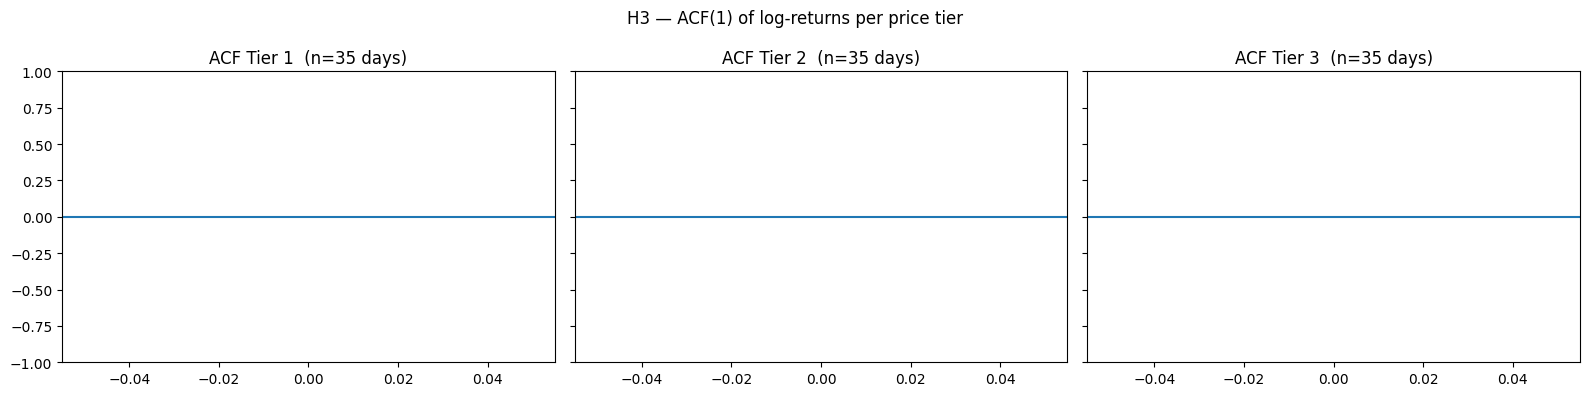

In [6]:
# Assign tier by latest snapshot price for each card
latest_price = (
    df.sort_values("snapshot_date").groupby("uuid")[["eur"]].last().reset_index()
)
latest_price["tier"] = pd.cut(
    latest_price["eur"],
    bins=[0, 100, 1000, np.inf],
    labels=[1, 2, 3],
)
df_tier = df.merge(latest_price[["uuid", "tier"]], on="uuid", how="left")

print("=== H3: Log-Return ACF(1) by Price Tier ===")
print()

MIN_N_ACF = 5
tier_results = []
for tier_val in [1, 2, 3]:
    tier_returns = (
        df_tier[df_tier["tier"] == tier_val]
        .groupby("snapshot_date")["log_return_1d"]
        .median()
        .sort_index()
        .dropna()
    )
    n_tier = len(tier_returns)

    if n_tier < MIN_N_ACF:
        print(
            f"Tier {tier_val}: n={n_tier} return observations — insufficient (need ≥{MIN_N_ACF})"
        )
        tier_results.append(
            {
                "tier": tier_val,
                "n_returns": n_tier,
                "acf_1": np.nan,
                "verdict": "INSUFFICIENT DATA",
            }
        )
        continue

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        acf_1_tier = tier_returns.autocorr(lag=1)

    strength = "STRONG (|r|>0.3)" if abs(acf_1_tier) > 0.3 else "WEAK (|r|≤0.3)"
    print(f"Tier {tier_val}: n={n_tier} days, ACF(1) = {acf_1_tier:.4f}  ({strength})")
    tier_results.append(
        {
            "tier": tier_val,
            "n_returns": n_tier,
            "acf_1": round(acf_1_tier, 4),
            "verdict": strength,
        }
    )

print()
all_insufficient = all(r["n_returns"] < MIN_N_ACF for r in tier_results)
if all_insufficient:
    rerun_h3 = (date_max_ts + pd.Timedelta(days=15)).date()
    print(f"All tiers insufficient at n_snapshots={n_snapshots}.")
    print(
        f"Re-run after: approximately {rerun_h3} (≥15 daily snapshots for initial ACF)."
    )
    print()
    print("Expected result:")
    print(
        "  Tier 3 (>€1000): higher |ACF(1)| — speculative momentum in expensive cards"
    )
    print("  Tier 1 (<€100):  lower |ACF(1)| — more liquid, more efficient bulk market")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    for ax, tier_val in zip(axes, [1, 2, 3]):
        tier_ret = (
            df_tier[df_tier["tier"] == tier_val]
            .groupby("snapshot_date")["log_return_1d"]
            .median()
            .sort_index()
            .dropna()
        )
        max_lags_t = max(min(30, len(tier_ret) // 2), 1) if len(tier_ret) >= 10 else 0
        if max_lags_t >= 1:
            plot_acf(tier_ret, lags=max_lags_t, alpha=0.05, ax=ax)
            ax.set_title(f"ACF Tier {tier_val}  (n={len(tier_ret)} days)")
        else:
            ax.text(
                0.5,
                0.5,
                f"Tier {tier_val}\nINSUFFICIENT\n(n={len(tier_ret)})",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=11,
            )
    plt.suptitle("H3 — ACF(1) of log-returns per price tier")
    plt.tight_layout()
    plt.show()

In [7]:
gold.close()

## 📋 Final Conclusions

```
DATA LIMITATIONS
─────────────────────────────────────────────────────────────────────────────
Snapshots:             36  (2026-05-26 to 2026-07-09; 9 calendar days missing
                        from the pipeline, e.g. 06-10, 06-24–06-28, 06-30, 07-03–07-04)
Market log-returns:    n=35  (34 of them are exactly 0.000000)
All test results:      STILL NOT FULLY TESTABLE — see per-hypothesis detail below

H1 — DISTRIBUTION STABILITY OVER TIME
─────────────────────────────────────────────────────────────────────────────
KS D:                  N/A — INSUFFICIENT DATA
  First half: 22 days (82,413 cards), second half: 14 days (82,069 cards)
  — second half is 1 day short of the ≥15-day-per-half requirement.
Stability verdict:     CANNOT ASSESS
Drift concern:         UNKNOWN — deferred

Temporal split decision (independent of H1):
  ALWAYS use temporal split — training on future data introduces target leakage
  regardless of whether the distribution is stable.
  Standard 80/20 temporal split (oldest 80% → train, newest 20% → test) is safe.

Re-run after: approximately 2026-08-08 (per the notebook's own computed retest date)

H2 — LOG-RETURN AUTOCORRELATION (MARKET-WIDE)
─────────────────────────────────────────────────────────────────────────────
n log-return observations:  35  (min required: 50)
max_lag (n//5 rule):        7  → still below the ≥10-lag reliability guidance
ACF(1):                     -0.0303 — unreliable at this n, and the market-wide
                             series is almost entirely flat (34/35 returns = 0.000000;
                             only 2026-07-07 moved, €0.27 → €0.26)
Ljung-Box:                  SKIPPED (n<50)

Feature price_change_1d_pct:  DEFERRED — insufficient data
Feature price_change_7d_pct:  DEFERRED — insufficient data

Re-run after: approximately 2026-08-28 (per the notebook's own computed retest date)

H3 — ACF(1) DIFFERS BY PRICE TIER
─────────────────────────────────────────────────────────────────────────────
All tiers: n=35 return observations per tier — no longer blocked by small n, but:
Tier 1 ACF(1):  NaN
Tier 2 ACF(1):  NaN
Tier 3 ACF(1):  NaN
Root cause: each tier's daily median log-return series has ZERO VARIANCE
  (statsmodels raised "invalid value encountered in divide" — avf[0]=0), not
  merely a small-sample issue. More snapshots alone will not fix this; the
  per-tier daily median price needs to actually move day-to-day.
Tier 3 > Tier 1 (speculative momentum): CANNOT ASSESS — no variance to compare

Re-run condition: not just "more snapshots" — needs the per-tier daily median
  price to show real movement (currently flat even across all 36 snapshots).

DECISIONS FOR MODEL
─────────────────────────────────────────────────────────────────────────────
Temporal train/test split required:     YES — always (prevents leakage)
Feature price_change_1d_pct:           DEFERRED — re-evaluate 2026-08-28
Feature price_change_7d_pct:           DEFERRED — re-evaluate 2026-08-28
Separate autoregression for Tier 3:    DEFERRED — H3 inconclusive due to
                                       zero-variance tier series, not just small n
Implication if H2 confirmed later:     add price_change_1d_pct and price_change_7d_pct
                                       as lag features; use rolling window = 7 days minimum

⚠ BLOCKING DEPENDENCY — 02_stationarity.ipynb (Stat 02)
─────────────────────────────────────────────────────────────────────────────
Stat 02 has a provisional, unconfirmed decision: model log-RETURNS (I(1) assumed)
vs log-LEVELS (I(0)). This was blocked until ≥30 snapshots (~2026-07-04).
That threshold has now been passed — 36 snapshots are available as of 2026-07-09.
This notebook does not re-derive Stat 02's verdict; check 02_stationarity.ipynb
directly for its current resolution.

Impact on this notebook (CDA 04) and the whole feature-engineering pipeline:
  • H1, H2, H3 test log-return properties. If Stat 02 confirms I(0) (stationary
    levels), the correct target is log-levels, not returns — and these hypotheses
    become moot for the feature-engineering phase.
  • EDA 04 ranks features by MI/correlation with log1p(EUR) LEVELS. If I(1) is
    confirmed, that ranking is NOT directly transferable to a log-return model.
    Static card attributes (edhrec_rank, rarity) explain price levels well but
    may explain short-term price changes poorly.
  • Once Stat 02 resolves: re-run EDA 04 with return-based MI before finalising
    the feature list in model_preparation/02.

RETEST SCHEDULE
─────────────────────────────────────────────────────────────────────────────
ACF/PACF visual:     2026-06-14  (threshold passed — see actual ACF/PACF above)
H3 tier ACF:         2026-06-19  (threshold passed — ran, but zero-variance NaN)
H1 KS stability:     2026-08-08  (≥30 snapshots is not enough; needs ≥15/half)
H2 Ljung-Box:        2026-08-28  (≥50 snapshots)
Stat 02 blocker:     2026-07-04  (threshold passed — verify resolution directly
                     in 02_stationarity.ipynb)
```